## Properties of Numerical Datatypes

So far, we have encountered the numeric Python types `integer` and `float`. These types can represent a wide range of values with high precision. This flexibility comes at a cost, however: higher-precision data types generally require more memory and may slow down computation, because *retrieving data from memory takes time*. This can become particularly important when working with large images, where millions of values need to be stored and processed.

For these reasons, Numpy offers a range of numeric datatypes, with different precision and other properties:

| Operator        | Meaning                         | Range                                                | Precision    |
|-----------------|---------------------------------|------------------------------------------------------|--------------|
| `bool`          | Boolean                         | $\{\text{True}, \text{False}\}$                      | binary       |
| `np.int8`       | 8-bit signed integer            | $[-128, 127]$                                        | integer      |
| `np.uint8`      | 8-bit unsigned integer          | $[0, 255]$                                           | integer      |
| `np.int16`      | 16-bit signed integer           | $[-32768, 32767]$                                    | integer      |
| `np.uint16`     | 16-bit unsigned integer         | $[0, 65535]$                                         | integer      |
| `np.int32`      | 32-bit signed integer           | $[-2^{31}, 2^{31}-1]$                                | integer      |
| `np.uint32`     | 32-bit unsigned integer         | $[0, 2^{32}-1]$                                      | integer      |
| `np.int64`      | 64-bit signed integer           | $[-2^{63}, 2^{63}-1]$                                | integer      |
| `np.uint64`     | 64-bit unsigned integer         | $[0, 2^{64}-1]$                                      | integer      |
| `np.float16`    | 16-bit floating point           | $[-65504, 65504]$                                    | 3-4 digits   |
| `np.float32`    | 32-bit floating point           | $\approx[-3.4 \times 10^{38}, 3.4 \times 10^{38}]$   | ~7 digits    |
| `np.float64`    | 64-bit floating point           | $\approx[-1.8 \times 10^{308}, 1.8 \times 10^{308}]$ | 15-16 digits |
| `np.complex64`  | 2×32-bit complex floating point | $\approx[-3.4 \times 10^{38}, 3.4 \times 10^{38}]$   | ~7 digits    |
| `np.complex128` | 2×64-bit complex floating point | $\approx[-1.8 \times 10^{308}, 1.8 \times 10^{308}]$ | 15-16 digits |

The number of bits indicate how much memory is required to store each value. Eight bits make up one *byte*, and a million of those is known as a *megabyte*, or MB.
So, storing a 1000×1000 image as `uint8` requires 1 MB, and storing the same image as `int64` requires 8 MB.

'Traditional' image formats (`jpg`, `png`, `gif`) commonly store red, green and blue pixel values as three 8-bit unsigned integers. For many photographs, the $2^8$=256 levels provided by `uint8` are sufficient.
Medical images, however, often require higher precision, a sign, and perhaps floating point numbers. The `float32` datatype is therefore a practical and safe choice for many applications. On the contrary, binary segmentation masks could be stored as Boolean values. Segmentation labels (such as 0 for background, 1 for gray matter, 2 for white matter, etc.) could be efficiently stored as `uint8`.

The Python datatype `float` is typically a 64-bit floating point number. In many other programming languages, such as C++ and MATLAB, a *float* or *single* refers to a 32 bit-bit floating point number, and the 64-bit floating point is known as a *double*. The 16-bit floating point is known as *half precision*, and is mainly used in applications where memory is a bottleneck and precision is less important, such in neural networks.

When creating a new Numpy array, the optional keyword argument `dtype` can be used to specify the datatype explicitly. If it is omitted, Numpy automatically chooses a type that can represent the given values:

In [1]:
import numpy as np

rgb = np.array([255, 140, 28], dtype=np.uint8)  # uint8 datatype specified
print(f'{rgb} is stored as {rgb.dtype}')

array = np.array([-1000, 500, 2000])  # Datatype not specified
print(f'{array} is stored as {array.dtype}')

binary_mask = array > 0  # Result from a logical operation
print(f'{binary_mask} is stored as {binary_mask.dtype}')

[255 140  28] is stored as uint8
[-1000   500  2000] is stored as int64
[False  True  True] is stored as bool


## Wrapping and Clipping

An existing Numpy array can be casted to another datatype using the `.astype()` method. *Use this with caution*, because Numpy will **not** check if all values can be represented in the new datatype. Numbers will not be *clipped* (i.e. rounded to the nearest possible value), but *wrapped*:

In [2]:
array = np.array([-1, 0, 1], dtype=np.int8)  # int8 allows storing signed numbers, such as -1.
array.astype(np.uint8)  # uint8 does not store signed numbers: -1 will be wrapped to (-1 + 256 = 255)!

array([255,   0,   1], dtype=uint8)

In [3]:
array = np.array([254, 255, 256], dtype=np.int16)  # int16 allows storing signed numbers up to 32676
array.astype(np.uint8)  # the maximum value of a uint8 is 255: 256 will be wrapped to (256 - 256 = 0)!

array([254, 255,   0], dtype=uint8)

If you would like to clip values, you should do that explicitly:

In [4]:
array = np.array([-1, 0, 1], dtype=np.int8)  # int8 allows storing signed numbers, such as -1.
array.clip(0, 255).astype(np.uint8)  # Clip to the range supported by uint8

array([0, 0, 1], dtype=uint8)

Wrapping also occurs in calculations, so make sure that the chosen datatype is appropriate for the image processing that you have in mind:

In [5]:
array = np.array([0, 50, 200], dtype=np.uint8)  # the maximum value of a uint8 is 255
array * 4  # (200×4 = 800) will be wrapped to (800 - 3×256 = 32):

array([  0, 200,  32], dtype=uint8)

In [6]:
array = np.array([0, 100, 200], dtype=np.float32)
(array ** 4) / 3 - 1000  # float32 has a sufficient range and precision:

array([-1.0000000e+03,  3.3332334e+07,  5.3333235e+08], dtype=float32)

Let's find out how this affects images. First, read a test image and print the datatype. The datatype is `int16`, which allows integer number up to 32767.

The image has data type int16, and the brightest pixel has the value 2191


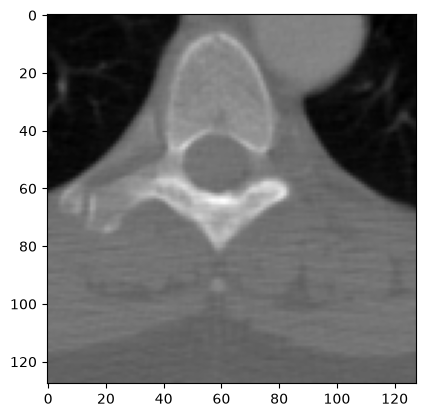

In [7]:
import matplotlib.pyplot as plt
from pydicom import dcmread
from pydicom.data import get_testdata_file

# Read a test image.
file_path = get_testdata_file("CT_small.dcm")  # Obtain the path to the test image.
dicom_image = dcmread(file_path)
image = dicom_image.pixel_array

print(f'The image has data type {image.dtype}, and the brightest pixel has the value {image.max()}')
plt.imshow(image, cmap="gray")
plt.show()

Now let's try squaring the pixel values: $2000^2=4\times10^{6}$, which does obviously not fit in `int16` 😱:

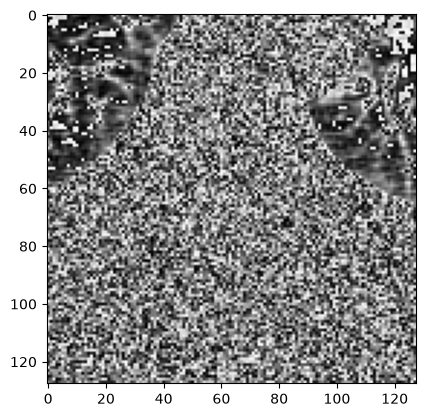

In [8]:
squared = image ** 2

plt.imshow(squared, cmap="gray")
plt.show()

Conversion to e.g. `float32` solves the issue:

The squared image has data type float32, and the brightest pixel has the value 4800481.0


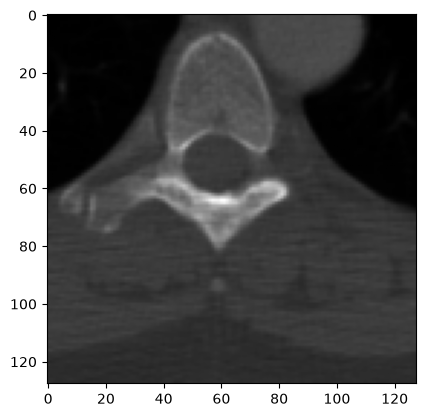

In [9]:
squared = image.astype(np.float32) ** 2
print(f'The squared image has data type {squared.dtype}, and the brightest pixel has the value {squared.max()}')

plt.imshow(squared, cmap="gray")
plt.show()

## Assignments
You've reached the end of this week's study material! During Friday's practical session, you can work on this week's assignment, which can be found in the [course materials](#course-materials).